# 🎯 Empathy Alignment: Baseline Model Evaluation

이 노트북에서는 **Llama-3.1-8B**와 **DeepSeek-7B** 모델을 4가지 공감 메트릭으로 평가합니다.

## 4가지 평가 차원
1. **Specificity (구체성)**: Brysbaert et al. (2014) - **40,000 단어 Lexicon**
2. **Reflection Level (반영 수준)**: PAIR Model (Min et al., 2022)
3. **Word Choice (단어 선택)**: NRC VAD Lexicon (Mohammad, 2018) - **20,000 단어 Lexicon**
4. **Diversity (다양성)**: Distinct-n (Li et al., 2016)

---
## 1. 환경 설정

In [1]:
# GPU 확인
!nvidia-smi

Tue Jan  6 01:41:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             51W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# 필요한 패키지 설치
!pip install -q transformers accelerate bitsandbytes
!pip install -q torch
!pip install -q huggingface_hub
!pip install -q tqdm pandas matplotlib requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 38.7 MB/s eta 0:00:00


In [3]:
# Google Drive 마운트
from google.colab import drive
drive.mount("/content/drive")

# 프로젝트 경로 설정
PROJECT_PATH = "/content/drive/MyDrive/empathy_alignment"

# 필요한 폴더 생성
import os
os.makedirs(f"{PROJECT_PATH}/data", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/data/lexicons", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/models", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/results", exist_ok=True)

print(f"Project path: {PROJECT_PATH}")
print("Folders created!")

Mounted at /content/drive
Project path: /content/drive/MyDrive/empathy_alignment
Folders created!


In [4]:
# HuggingFace 로그인 (Llama 모델 접근을 위해 필요)
# https://huggingface.co/settings/tokens 에서 토큰 발급
# https://huggingface.co/meta-llama 에서 Llama 라이센스 동의 필요
from huggingface_hub import login
login()

---
## 2. Lexicon 데이터 다운로드

### 필요한 데이터:
- **Brysbaert Concreteness Ratings**: 40,000 영어 단어의 구체성 점수
- **NRC VAD Lexicon**: 20,000 영어 단어의 Valence-Arousal-Dominance 점수

In [6]:
import requests
import os

LEXICON_PATH = f"{PROJECT_PATH}/data/lexicons"
CONCRETENESS_FILE = f"{LEXICON_PATH}/concreteness_ratings.txt"

# 기존 잘못된 파일 삭제
if os.path.exists(CONCRETENESS_FILE):
    os.remove(CONCRETENESS_FILE)
    print("[OK] Removed old file")

# 올바른 URL로 다시 다운로드
CONCRETENESS_URL = "https://raw.githubusercontent.com/ArtsEngine/concreteness/master/Concreteness_ratings_Brysbaert_et_al_BRM.txt"

print("Downloading Brysbaert Concreteness Ratings (40,000 words)...")
response = requests.get(CONCRETENESS_URL)

if response.status_code == 200:
    with open(CONCRETENESS_FILE, "w", encoding="utf-8") as f:
        f.write(response.text)
    print(f"[OK] Saved to {CONCRETENESS_FILE}")
else:
    print(f"[ERROR] Download failed: {response.status_code}")

# 파일 확인
with open(CONCRETENESS_FILE, "r", encoding="utf-8") as f:
    lines = f.readlines()
print(f"Total lines: {len(lines)}")
print(f"Header: {lines[0].strip()}")
print(f"Sample: {lines[1].strip()}")

[OK] Removed old file
[OK] Saved to /content/drive/MyDrive/empathy_alignment/data/lexicons/concreteness_ratings.txt
Total lines: 39955
Header: Word	Bigram	Conc.M	Conc.SD	Unknown	Total	Percent_known	SUBTLEX	Dom_Pos
Sample: roadsweeper	0	4.85	0.37	1	27	0.96	0	0


In [11]:
# ========== NRC VAD Lexicon 다운로드 ==========
# 출처: https://saifmohammad.com/WebPages/nrc-vad.html
# 원본 논문: Mohammad (2018)

import os

LEXICON_PATH = f"{PROJECT_PATH}/data/lexicons"
VAD_FILE = f"{LEXICON_PATH}/NRC-VAD-Lexicon-v2.1.txt"

# 파일 존재 확인
if os.path.exists(VAD_FILE):
    print(f"[OK] VAD Lexicon found: {VAD_FILE}")

    # 파일 내용 확인
    with open(VAD_FILE, "r", encoding="utf-8") as f:
        lines = f.readlines()

    print(f"Total lines: {len(lines)}")
    print(f"First line: {lines[0].strip()}")
    print(f"Second line: {lines[1].strip()}")
    print(f"Third line: {lines[2].strip()}")
else:
    print(f"[ERROR] VAD Lexicon not found!")
    print(f"Please download from: https://saifmohammad.com/WebPages/nrc-vad.html")
    print(f"And upload to: {VAD_FILE}")

[OK] VAD Lexicon found: /content/drive/MyDrive/empathy_alignment/data/lexicons/NRC-VAD-Lexicon-v2.1.txt
Total lines: 54802
First line: term	valence	arousal	dominance
Second line: a battery	0.134	-0.298	-0.096
Third line: a bit	-0.096	-0.264	-0.214


---
## 3. 메트릭 코드 정의 (Full Lexicon 버전)

In [12]:
import re
import numpy as np
from typing import List, Dict, Optional, Tuple
from collections import Counter
from dataclasses import dataclass, asdict
from datetime import datetime
import json

print("[OK] Imports ready")

[OK] Imports ready


In [13]:
# ========== Specificity Metric (Full Lexicon: 40,000 words) ==========
class SpecificityMetric:
    """
    구체성 메트릭 - Brysbaert et al. (2014) Concreteness Ratings 기반

    40,000개 영어 단어에 대한 구체성 점수 (1-5점)
    - 5점: 매우 구체적 (감각적으로 경험 가능) - e.g., apple, dog, car
    - 1점: 매우 추상적 (개념적) - e.g., freedom, truth, idea
    """

    def __init__(self, lexicon_path: str = None):
        self.lexicon = {}
        if lexicon_path:
            self.load_lexicon(lexicon_path)
        else:
            self._load_fallback_lexicon()

    def load_lexicon(self, filepath: str):
        """Brysbaert Concreteness Ratings 파일 로드"""
        try:
            with open(filepath, "r", encoding="utf-8") as f:
                lines = f.readlines()

            # 헤더 스킵 (첫 줄)
            for line in lines[1:]:
                parts = line.strip().split("\t")
                if len(parts) >= 3:
                    word = parts[0].lower().strip()
                    try:
                        score = float(parts[2])  # Conc.M 컬럼
                        self.lexicon[word] = score
                    except (ValueError, IndexError):
                        continue

            print(f"[OK] Loaded {len(self.lexicon):,} words from Concreteness Lexicon")
        except FileNotFoundError:
            print(f"[WARNING] File not found: {filepath}")
            self._load_fallback_lexicon()

    def _load_fallback_lexicon(self):
        """파일이 없을 경우 기본 샘플 lexicon 사용"""
        self.lexicon = {
            "apple": 5.0, "dog": 4.98, "cat": 4.97, "car": 4.95, "house": 4.93,
            "tree": 4.92, "book": 4.89, "table": 4.88, "phone": 4.85, "computer": 4.82,
            "understand": 2.60, "sorry": 2.70, "feel": 3.10, "hope": 2.30, "love": 2.45,
        }
        print(f"[WARNING] Using fallback lexicon ({len(self.lexicon)} words)")

    def compute(self, text: str) -> Dict:
        """텍스트의 구체성 점수 계산"""
        words = re.findall(r"\b[a-z]+\b", text.lower())
        if not words:
            return {"score": 0.0, "coverage": 0.0, "matched_words": 0, "total_words": 0}

        scores = [self.lexicon[w] for w in words if w in self.lexicon]
        if not scores:
            return {"score": 0.0, "coverage": 0.0, "matched_words": 0, "total_words": len(words)}

        return {
            "score": float(np.mean(scores)),
            "coverage": len(scores) / len(words),
            "matched_words": len(scores),
            "total_words": len(words)
        }

# Lexicon 로드
CONCRETENESS_FILE = f"{PROJECT_PATH}/data/lexicons/concreteness_ratings.txt"
specificity_metric = SpecificityMetric(CONCRETENESS_FILE)

# 테스트
test_result = specificity_metric.compute("I understand how you feel about losing your dog.")
print(f"Test result: {test_result}")

[OK] Loaded 39,954 words from Concreteness Lexicon
Test result: {'score': 2.802222222222222, 'coverage': 1.0, 'matched_words': 9, 'total_words': 9}


In [14]:
# ========== Reflection Level Metric ==========
class ReflectionLevelMetric:
    """
    반영 수준 메트릭 - PAIR Model (Min et al., 2022) 및 MISC 2.5 (Houck et al., 2012) 기반

    7단계 반영 수준 (0-6):
    - Level 0: 반영 없음
    - Level 1-2: Simple Reflection (단순 반복/확인)
    - Level 3-4: Feeling Reflection (감정 인식 및 반영)
    - Level 5-6: Complex Reflection (깊은 의미/감정 탐색)

    References:
    - Min, S., et al. (2022). PAIR: Prompt-aware margin ranking for counselor reflection generation. ACL.
    - Houck, J. M., et al. (2012). Motivational Interviewing Skill Code (MISC) 2.5.
    """

    def __init__(self):
        # Complex Reflection 패턴 (Level 5-6)
        self.complex_patterns = [
            r"it seems like .+ means .+ to you",
            r"beneath .+ there seems to be",
            r"on a deeper level",
            r"what that .+ represents",
            r"i sense that .+ is really about",
            r"there's something .+ underneath",
            r"it sounds like .+ goes beyond",
            r"what i'm hearing is .+ and also",
            r"the .+ seems connected to",
            r"i wonder if .+ is related to",
        ]

        # Feeling Reflection 패턴 (Level 3-4)
        self.feeling_patterns = [
            r"you('re| are) feeling",
            r"you feel",
            r"you seem",
            r"sounds like you('re| are)",
            r"it sounds like",
            r"that must (be|feel|have been)",
            r"i can (see|hear|sense|imagine) (that |how )?you",
            r"you sound",
            r"it seems like you",
            r"you appear to be",
            r"i get the sense that you",
            r"what i hear is that you",
            r"you're experiencing",
            r"that sounds (really |very )?(hard|difficult|painful|frustrating|overwhelming)",
            r"it must (be|feel) (so |really |very )?(hard|difficult|painful)",
        ]

        # Simple Reflection 패턴 (Level 1-2)
        self.simple_patterns = [
            r"so you",
            r"you('re| are) saying",
            r"you mentioned",
            r"i hear you",
            r"i understand",
            r"i see",
            r"that('s| is) (hard|difficult|tough|challenging)",
            r"you said",
            r"you told me",
            r"you shared",
            r"right,",
            r"okay,",
            r"i get it",
            r"i hear what you",
            r"that makes sense",
        ]

        # Empathy Booster 패턴 (추가 점수)
        self.empathy_boosters = [
            r"i('m| am) (so |really |truly )?sorry (to hear|that|for)",
            r"that must (be|have been) (really |very |so )?(hard|difficult|painful|devastating|heartbreaking)",
            r"i can only imagine",
            r"thank you for (sharing|telling|trusting|opening up)",
            r"i appreciate you (sharing|telling|trusting)",
            r"that takes (courage|strength|a lot)",
            r"i'm here for you",
            r"you're not alone",
            r"i care about",
            r"my heart goes out to you",
            r"i can't imagine how (hard|difficult|painful)",
        ]

    def compute(self, response: str, context: Optional[str] = None) -> Dict:
        """응답의 반영 수준 계산"""
        text = response.lower().strip()

        counts = {"complex": 0, "feeling": 0, "simple": 0, "booster": 0}

        for p in self.complex_patterns:
            if re.search(p, text):
                counts["complex"] += 1

        for p in self.feeling_patterns:
            if re.search(p, text):
                counts["feeling"] += 1

        for p in self.simple_patterns:
            if re.search(p, text):
                counts["simple"] += 1

        for p in self.empathy_boosters:
            if re.search(p, text):
                counts["booster"] += 1

        # 레벨 계산
        if counts["complex"] > 0:
            level = 5 + min(counts["complex"], 1)  # 5-6
        elif counts["feeling"] > 0:
            level = 3 + min(counts["feeling"], 2)  # 3-5
        elif counts["simple"] > 0:
            level = 1 + min(counts["simple"], 1)   # 1-2
        else:
            level = 0

        # Booster로 레벨 상향 (최대 6)
        if counts["booster"] > 0 and level < 6:
            level = min(level + 1, 6)

        return {
            "level": level,
            "normalized_score": level / 6.0,
            "counts": counts
        }

reflection_metric = ReflectionLevelMetric()

# 테스트
test_result = reflection_metric.compute("I'm so sorry to hear that. It sounds like you're feeling really overwhelmed right now.")
print(f"Test result: {test_result}")

Test result: {'level': 6, 'normalized_score': 1.0, 'counts': {'complex': 0, 'feeling': 3, 'simple': 0, 'booster': 1}}


In [15]:
# ========== Word Choice Metric (v2.1 지원) ==========
class WordChoiceMetric:
    """
    NRC VAD Lexicon v2.1 지원 (55,000 단어)
    v2.1 값 범위: -1 ~ 1 → 0 ~ 1로 정규화
    """

    IDEAL_VALENCE = 0.65
    IDEAL_AROUSAL = 0.45
    IDEAL_DOMINANCE = 0.40

    def __init__(self, lexicon_path: str = None):
        self.vad_lexicon = {}
        if lexicon_path:
            self.load_lexicon(lexicon_path)

    def load_lexicon(self, filepath: str):
        """NRC VAD Lexicon 파일 로드 (v1, v2.1 모두 지원)"""
        try:
            with open(filepath, "r", encoding="utf-8") as f:
                lines = f.readlines()

            # 헤더 확인 (v2.1: term, v1: Word)
            header = lines[0].strip().lower()
            is_v2 = "term" in header

            for line in lines[1:]:  # 헤더 스킵
                parts = line.strip().split("\t")
                if len(parts) >= 4:
                    word = parts[0].lower().strip()
                    try:
                        v = float(parts[1])
                        a = float(parts[2])
                        d = float(parts[3])

                        # v2.1은 -1~1 범위 → 0~1로 정규화
                        if is_v2:
                            v = (v + 1) / 2
                            a = (a + 1) / 2
                            d = (d + 1) / 2

                        self.vad_lexicon[word] = {"v": v, "a": a, "d": d}
                    except (ValueError, IndexError):
                        continue

            version = "v2.1" if is_v2 else "v1"
            print(f"[OK] Loaded {len(self.vad_lexicon):,} words from VAD Lexicon ({version})")
        except FileNotFoundError:
            print(f"[WARNING] File not found: {filepath}")

    def compute(self, text: str) -> Dict:
        """텍스트의 VAD 점수 및 공감 정렬도 계산"""
        words = re.findall(r"\b[a-z]+\b", text.lower())
        if not words:
            return {
                "valence": 0.5, "arousal": 0.5, "dominance": 0.5,
                "empathy_alignment": 0.0, "coverage": 0.0,
                "matched_words": 0, "total_words": 0
            }

        v_scores, a_scores, d_scores = [], [], []
        for w in words:
            if w in self.vad_lexicon:
                v_scores.append(self.vad_lexicon[w]["v"])
                a_scores.append(self.vad_lexicon[w]["a"])
                d_scores.append(self.vad_lexicon[w]["d"])

        if not v_scores:
            return {
                "valence": 0.5, "arousal": 0.5, "dominance": 0.5,
                "empathy_alignment": 0.0, "coverage": 0.0,
                "matched_words": 0, "total_words": len(words)
            }

        v = np.mean(v_scores)
        a = np.mean(a_scores)
        d = np.mean(d_scores)

        # Empathy alignment
        distance = (abs(v - self.IDEAL_VALENCE) +
                   abs(a - self.IDEAL_AROUSAL) +
                   abs(d - self.IDEAL_DOMINANCE)) / 3.0
        alignment = max(0.0, min(1.0, 1.0 - distance))

        return {
            "valence": float(v),
            "arousal": float(a),
            "dominance": float(d),
            "empathy_alignment": float(alignment),
            "coverage": len(v_scores) / len(words),
            "matched_words": len(v_scores),
            "total_words": len(words)
        }

# Lexicon 로드 (v2.1 파일명으로 변경)
VAD_FILE = f"{PROJECT_PATH}/data/lexicons/NRC-VAD-Lexicon-v2.1.txt"
word_choice_metric = WordChoiceMetric(VAD_FILE)

# 테스트
test_result = word_choice_metric.compute("I'm sorry to hear that. I understand how difficult this must be.")
print(f"Test result: {test_result}")

[OK] Loaded 54,801 words from VAD Lexicon (v2.1)
Test result: {'valence': 0.5239, 'arousal': 0.45255, 'dominance': 0.495, 'empathy_alignment': 0.92545, 'coverage': 0.7692307692307693, 'matched_words': 10, 'total_words': 13}


In [16]:
# ========== Diversity Metric ==========
class DiversityMetric:
    """
    다양성 메트릭 - Distinct-n (Li et al., 2016) 기반

    - Distinct-1: 고유 unigram 비율 (단어 수준 다양성)
    - Distinct-2: 고유 bigram 비율 (구문 수준 다양성)
    - Diversity Score: 0.4 * D1 + 0.6 * D2 (종합 점수)

    Reference:
    Li, J., Galley, M., Brockett, C., Gao, J., & Dolan, B. (2016).
    A diversity-promoting objective function for neural conversation models. NAACL-HLT.
    """

    def compute(self, text: str) -> Dict:
        """개별 텍스트의 다양성 계산"""
        tokens = re.findall(r"\b[a-z]+\b|[.,!?]", text.lower())
        if not tokens:
            return {"distinct_1": 0.0, "distinct_2": 0.0, "diversity_score": 0.0, "token_count": 0}

        # Distinct-1
        d1 = len(set(tokens)) / len(tokens)

        # Distinct-2
        bigrams = [tuple(tokens[i:i+2]) for i in range(len(tokens)-1)]
        d2 = len(set(bigrams)) / len(bigrams) if bigrams else 0.0

        # 종합 점수
        diversity_score = 0.4 * d1 + 0.6 * d2

        return {
            "distinct_1": float(d1),
            "distinct_2": float(d2),
            "diversity_score": float(diversity_score),
            "token_count": len(tokens)
        }

    def compute_corpus(self, texts: List[str]) -> Dict:
        """전체 코퍼스의 다양성 계산"""
        all_tokens = []
        for t in texts:
            all_tokens.extend(re.findall(r"\b[a-z]+\b|[.,!?]", t.lower()))

        if not all_tokens:
            return {"corpus_distinct_1": 0.0, "corpus_distinct_2": 0.0, "total_tokens": 0}

        d1 = len(set(all_tokens)) / len(all_tokens)
        bigrams = [tuple(all_tokens[i:i+2]) for i in range(len(all_tokens)-1)]
        d2 = len(set(bigrams)) / len(bigrams) if bigrams else 0.0

        return {
            "corpus_distinct_1": float(d1),
            "corpus_distinct_2": float(d2),
            "total_tokens": len(all_tokens),
            "unique_tokens": len(set(all_tokens))
        }

diversity_metric = DiversityMetric()

# 테스트
test_result = diversity_metric.compute("I understand how you feel. That must be really hard for you.")
print(f"Test result: {test_result}")

Test result: {'distinct_1': 0.8571428571428571, 'distinct_2': 1.0, 'diversity_score': 0.9428571428571428, 'token_count': 14}


In [17]:
# ========== Empathy Evaluator (통합 평가기) ==========
@dataclass
class EmpathyReport:
    """공감 평가 리포트"""
    model_name: str
    num_samples: int
    mean_specificity: float
    mean_reflection_level: float
    mean_word_choice: float
    mean_diversity: float
    overall_score: float
    details: Dict = None

    def to_dict(self):
        return asdict(self)

class EmpathyEvaluator:
    """4가지 메트릭을 통합한 공감 평가기"""

    def __init__(self, spec_metric, refl_metric, word_metric, div_metric):
        self.spec = spec_metric
        self.refl = refl_metric
        self.word = word_metric
        self.div = div_metric

    def evaluate_single(self, response: str, context: str = None) -> Dict:
        """단일 응답 평가"""
        return {
            "specificity": self.spec.compute(response),
            "reflection": self.refl.compute(response, context),
            "word_choice": self.word.compute(response),
            "diversity": self.div.compute(response)
        }

    def evaluate(self, responses: List[str], contexts: List[str] = None,
                 model_name: str = "Unknown") -> EmpathyReport:
        """다중 응답 평가"""
        if contexts is None:
            contexts = [None] * len(responses)

        spec_scores, refl_scores, word_scores, div_scores = [], [], [], []
        detailed_results = []

        for resp, ctx in zip(responses, contexts):
            result = self.evaluate_single(resp, ctx)
            spec_scores.append(result["specificity"]["score"])
            refl_scores.append(result["reflection"]["level"])
            word_scores.append(result["word_choice"]["empathy_alignment"])
            div_scores.append(result["diversity"]["diversity_score"])
            detailed_results.append(result)

        corpus_div = self.div.compute_corpus(responses)

        mean_spec = np.mean(spec_scores)
        mean_refl = np.mean(refl_scores)
        mean_word = np.mean(word_scores)
        mean_div = np.mean(div_scores)

        # Overall score (정규화 후 평균)
        overall = (0.25 * (mean_spec / 5.0) +
                   0.25 * (mean_refl / 6.0) +
                   0.25 * mean_word +
                   0.25 * mean_div)

        return EmpathyReport(
            model_name=model_name,
            num_samples=len(responses),
            mean_specificity=float(mean_spec),
            mean_reflection_level=float(mean_refl),
            mean_word_choice=float(mean_word),
            mean_diversity=float(mean_div),
            overall_score=float(overall),
            details={
                "corpus_distinct_1": corpus_div["corpus_distinct_1"],
                "corpus_distinct_2": corpus_div["corpus_distinct_2"],
                "spec_std": float(np.std(spec_scores)),
                "refl_std": float(np.std(refl_scores)),
                "word_std": float(np.std(word_scores)),
                "div_std": float(np.std(div_scores)),
                "spec_coverage": float(np.mean([r["specificity"]["coverage"] for r in detailed_results])),
                "word_coverage": float(np.mean([r["word_choice"]["coverage"] for r in detailed_results])),
            }
        )

    def print_report(self, report: EmpathyReport):
        """리포트 출력"""
        print("\n" + "="*65)
        print("📊 EMPATHY EVALUATION REPORT")
        print("="*65)
        print(f"Model: {report.model_name}")
        print(f"Samples: {report.num_samples}")
        print("-"*65)
        print(f"  📐 Specificity:        {report.mean_specificity:.3f} / 5.0  (coverage: {report.details['spec_coverage']:.1%})")
        print(f"  🪞 Reflection Level:   {report.mean_reflection_level:.2f} / 6.0")
        print(f"  💬 Word Choice:        {report.mean_word_choice:.3f} / 1.0  (coverage: {report.details['word_coverage']:.1%})")
        print(f"  🎨 Diversity:          {report.mean_diversity:.3f} / 1.0")
        print("-"*65)
        print(f"  🎯 OVERALL SCORE:      {report.overall_score:.3f} / 1.0")
        print("="*65)

# 평가기 초기화
evaluator = EmpathyEvaluator(specificity_metric, reflection_metric, word_choice_metric, diversity_metric)
print("[OK] EmpathyEvaluator ready!")

[OK] EmpathyEvaluator ready!


---
## 4. 테스트 프롬프트 정의

In [18]:
# 공감적 응답이 필요한 상황들 (10가지)
TEST_PROMPTS = [
    {"context": "I just lost my job today. I've been working there for 5 years and they just let me go without any warning.", "emotion": "sadness/shock"},
    {"context": "My best friend hasn't talked to me in weeks. I don't know what I did wrong.", "emotion": "confusion/hurt"},
    {"context": "I finally passed my medical exam after failing three times! I can't believe it!", "emotion": "joy/relief"},
    {"context": "My parents are getting divorced after 30 years of marriage. I don't know how to feel.", "emotion": "confusion/sadness"},
    {"context": "I've been feeling really anxious lately. I can't sleep and I keep worrying about everything.", "emotion": "anxiety"},
    {"context": "My dog passed away yesterday. He was with me for 12 years.", "emotion": "grief"},
    {"context": "I got accepted into my dream university! All the hard work finally paid off.", "emotion": "excitement/pride"},
    {"context": "I feel like nobody understands me. Even my closest friends don't seem to get what I'm going through.", "emotion": "loneliness"},
    {"context": "My partner forgot our anniversary again. It's the third year in a row.", "emotion": "disappointment/hurt"},
    {"context": "I just found out I'm going to be a parent. I'm excited but also terrified.", "emotion": "mixed emotions"},
]

SYSTEM_PROMPT = """You are an empathetic listener. When someone shares their feelings or experiences with you, respond with genuine empathy and understanding.
- Acknowledge their emotions
- Show that you understand their situation
- Be supportive without being dismissive
- Avoid giving unsolicited advice unless asked

Respond naturally and warmly, as a caring friend would."""

print(f"[OK] Loaded {len(TEST_PROMPTS)} test prompts")
print(f"Emotions covered: {[p['emotion'] for p in TEST_PROMPTS]}")

[OK] Loaded 10 test prompts
Emotions covered: ['sadness/shock', 'confusion/hurt', 'joy/relief', 'confusion/sadness', 'anxiety', 'grief', 'excitement/pride', 'loneliness', 'disappointment/hurt', 'mixed emotions']


---
## 5. 모델 로드 및 응답 생성 함수

In [21]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm
import gc

def load_model(model_name: str):
    """모델 로드 (H100/A100에서는 양자화 불필요)"""
    print(f"\n{'='*50}")
    print(f"Loading: {model_name}")
    print(f"{'='*50}")

    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="auto",
        trust_remote_code=True,
        torch_dtype=torch.float16,
    )

    print(f"[OK] Model loaded! Device: {next(model.parameters()).device}")
    return model, tokenizer

def generate_response(model, tokenizer, context: str, max_new_tokens: int = 256) -> str:
    """응답 생성"""
    if hasattr(tokenizer, "apply_chat_template") and tokenizer.chat_template:
        messages = [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": context}]
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    else:
        prompt = f"System: {SYSTEM_PROMPT}\n\nUser: {context}\n\nAssistant:"

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=max_new_tokens, temperature=0.7,
            do_sample=True, top_p=0.9, pad_token_id=tokenizer.pad_token_id
        )

    return tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

def cleanup():
    """GPU 메모리 정리"""
    gc.collect()
    torch.cuda.empty_cache()
    print("[CLEAN] GPU memory cleaned!")

print("[OK] Functions ready!")

[OK] Functions ready!


---
## 6. Llama-3.1-8B 평가

In [22]:
# Llama 모델 로드
LLAMA_MODEL = "meta-llama/Meta-Llama-3.1-8B-Instruct"
llama_model, llama_tokenizer = load_model(LLAMA_MODEL)


Loading: meta-llama/Meta-Llama-3.1-8B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

[OK] Model loaded! Device: cuda:0


In [23]:
# Llama 응답 생성
llama_responses = []
llama_contexts = []

print("Generating Llama responses...")
for prompt_data in tqdm(TEST_PROMPTS):
    context = prompt_data["context"]
    response = generate_response(llama_model, llama_tokenizer, context)
    llama_responses.append(response)
    llama_contexts.append(context)
    print(f"\n[Context]: {context[:50]}...")
    print(f"[Response]: {response[:100]}...")

Generating Llama responses...


 10%|█         | 1/10 [00:04<00:43,  4.82s/it]


[Context]: I just lost my job today. I've been working there ...
[Response]: I'm so sorry to hear that. Losing a job can be really tough, especially when it feels unexpected. Fi...


 20%|██        | 2/10 [00:08<00:32,  4.08s/it]


[Context]: My best friend hasn't talked to me in weeks. I don...
[Response]: I can only imagine how tough this must be for you. It sounds like you're really missing your friend ...


...


[Context]: I feel like nobody understands me. Even my closest...
[Response]: I'm so sorry to hear that you're feeling that way. It can be really isolating and lonely when it fee...


 90%|█████████ | 9/10 [00:37<00:03,  3.84s/it]


[Context]: My partner forgot our anniversary again. It's the ...
[Response]: I'm so sorry to hear that. It sounds like you're really hurting right now. Forgetting such a special...


100%|██████████| 10/10 [00:42<00:00,  4.28s/it]


[Context]: I just found out I'm going to be a parent. I'm exc...
[Response]: Congratulations on your pregnancy! It's completely normal to feel a mix of emotions right now. Being...


In [24]:
# Llama 평가
llama_report = evaluator.evaluate(llama_responses, llama_contexts, LLAMA_MODEL)
evaluator.print_report(llama_report)

# 결과 저장
with open(f"{PROJECT_PATH}/results/llama_evaluation.json", "w") as f:
    json.dump({
        "model": LLAMA_MODEL,
        "responses": llama_responses,
        "contexts": llama_contexts,
        "report": llama_report.to_dict()
    }, f, indent=2)
print(f"[OK] Saved to {PROJECT_PATH}/results/llama_evaluation.json")


📊 EMPATHY EVALUATION REPORT
Model: meta-llama/Meta-Llama-3.1-8B-Instruct
Samples: 10
-----------------------------------------------------------------
  📐 Specificity:        2.436 / 5.0  (coverage: 89.3%)
  🪞 Reflection Level:   4.80 / 6.0
  💬 Word Choice:        0.921 / 1.0  (coverage: 73.0%)
  🎨 Diversity:          0.819 / 1.0
-----------------------------------------------------------------
  🎯 OVERALL SCORE:      0.757 / 1.0
[OK] Saved to /content/drive/MyDrive/empathy_alignment/results/llama_evaluation.json


In [ ]:
# Llama 메모리 정리
del llama_model, llama_tokenizer
cleanup()

---
## 7. DeepSeek-7B 평가

In [25]:
# DeepSeek 모델 로드
DEEPSEEK_MODEL = "deepseek-ai/deepseek-llm-7b-chat"
deepseek_model, deepseek_tokenizer = load_model(DEEPSEEK_MODEL)


Loading: deepseek-ai/deepseek-llm-7b-chat


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/594 [00:00<?, ?B/s]

pytorch_model.bin.index.json: 0.00B [00:00, ?B/s]

...

pytorch_model-00001-of-00002.bin:   0%|          | 0.00/9.97G [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

[OK] Model loaded! Device: cuda:0


In [26]:
# DeepSeek 응답 생성
deepseek_responses = []
deepseek_contexts = []

print("Generating DeepSeek responses...")
for prompt_data in tqdm(TEST_PROMPTS):
    context = prompt_data["context"]
    response = generate_response(deepseek_model, deepseek_tokenizer, context)
    deepseek_responses.append(response)
    deepseek_contexts.append(context)
    print(f"\n[Context]: {context[:50]}...")
    print(f"[Response]: {response[:100]}...")

Generating DeepSeek responses...


 10%|█         | 1/10 [00:08<01:18,  8.72s/it]


[Context]: I just lost my job today. I've been working there ...
[Response]: I'm sorry to hear that you lost your job today. Losing a job can be a difficult and stressful experi...


 20%|██        | 2/10 [00:16<01:03,  7.99s/it]


[Context]: My best friend hasn't talked to me in weeks. I don...
[Response]: I'm sorry to hear that your best friend hasn't been in touch with you. It can be difficult to unders...


...


[Context]: I feel like nobody understands me. Even my closest...
[Response]: It must be difficult when you feel like you're struggling with something that others can't relate to...


 90%|█████████ | 9/10 [00:40<00:03,  3.69s/it]


[Context]: My partner forgot our anniversary again. It's the ...
[Response]: Oh, I'm sorry to hear that. It can be really disappointing when someone forgets an important occasio...


100%|██████████| 10/10 [00:45<00:00,  4.55s/it]


[Context]: I just found out I'm going to be a parent. I'm exc...
[Response]: Oh wow, congratulations on your exciting news! I can understand how you might be feeling both excite...


In [27]:
# DeepSeek 평가
deepseek_report = evaluator.evaluate(deepseek_responses, deepseek_contexts, DEEPSEEK_MODEL)
evaluator.print_report(deepseek_report)

# 결과 저장
with open(f"{PROJECT_PATH}/results/deepseek_evaluation.json", "w") as f:
    json.dump({
        "model": DEEPSEEK_MODEL,
        "responses": deepseek_responses,
        "contexts": deepseek_contexts,
        "report": deepseek_report.to_dict()
    }, f, indent=2)
print(f"[OK] Saved to {PROJECT_PATH}/results/deepseek_evaluation.json")


📊 EMPATHY EVALUATION REPORT
Model: deepseek-ai/deepseek-llm-7b-chat
Samples: 10
-----------------------------------------------------------------
  📐 Specificity:        2.427 / 5.0  (coverage: 89.1%)
  🪞 Reflection Level:   2.70 / 6.0
  💬 Word Choice:        0.929 / 1.0  (coverage: 76.4%)
  🎨 Diversity:          0.834 / 1.0
-----------------------------------------------------------------
  🎯 OVERALL SCORE:      0.674 / 1.0
[OK] Saved to /content/drive/MyDrive/empathy_alignment/results/deepseek_evaluation.json


In [ ]:
# DeepSeek 메모리 정리
del deepseek_model, deepseek_tokenizer
cleanup()

---
## 8. 모델 비교

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# 비교 테이블
comparison = pd.DataFrame({
    "Model": ["Llama-3.1-8B", "DeepSeek-7B"],
    "Specificity": [llama_report.mean_specificity, deepseek_report.mean_specificity],
    "Reflection": [llama_report.mean_reflection_level, deepseek_report.mean_reflection_level],
    "Word Choice": [llama_report.mean_word_choice, deepseek_report.mean_word_choice],
    "Diversity": [llama_report.mean_diversity, deepseek_report.mean_diversity],
    "Overall": [llama_report.overall_score, deepseek_report.overall_score],
})

print("\n" + "="*70)
print("📊 MODEL COMPARISON")
print("="*70)
print(comparison.to_string(index=False))
print("="*70)


📊 MODEL COMPARISON
       Model  Specificity  Reflection  Word Choice  Diversity  Overall
Llama-3.1-8B     2.436339         4.8     0.920896   0.819056 0.756805
 DeepSeek-7B     2.426827         2.7     0.928725   0.833789 0.674470


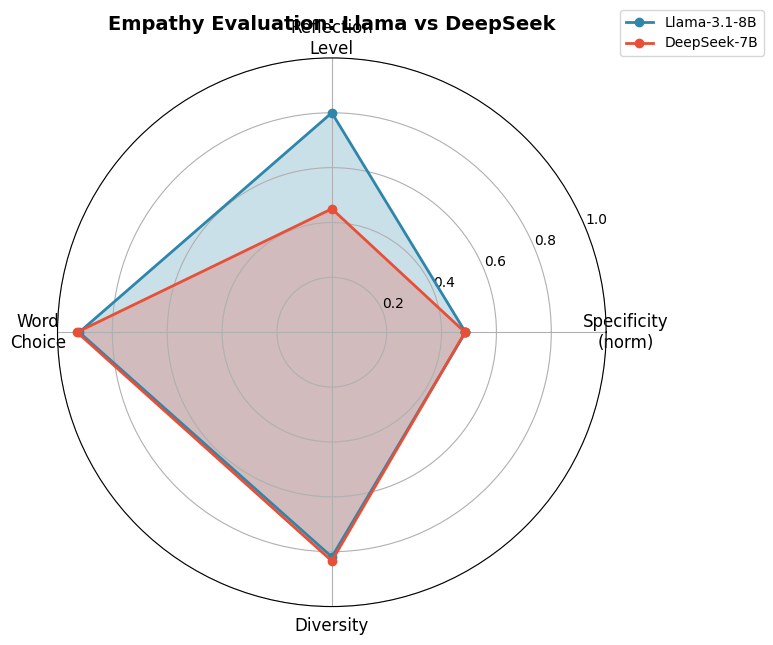


[OK] Chart saved!


In [29]:
# 레이더 차트
categories = ["Specificity\n(norm)", "Reflection\nLevel", "Word\nChoice", "Diversity"]
N = len(categories)

llama_scores = [llama_report.mean_specificity/5, llama_report.mean_reflection_level/6,
                llama_report.mean_word_choice, llama_report.mean_diversity]
deepseek_scores = [deepseek_report.mean_specificity/5, deepseek_report.mean_reflection_level/6,
                   deepseek_report.mean_word_choice, deepseek_report.mean_diversity]

angles = [n / N * 2 * np.pi for n in range(N)]
angles += angles[:1]
llama_scores += llama_scores[:1]
deepseek_scores += deepseek_scores[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, llama_scores, "o-", linewidth=2, label="Llama-3.1-8B", color="#2E86AB")
ax.fill(angles, llama_scores, alpha=0.25, color="#2E86AB")
ax.plot(angles, deepseek_scores, "o-", linewidth=2, label="DeepSeek-7B", color="#E94F37")
ax.fill(angles, deepseek_scores, alpha=0.25, color="#E94F37")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 1)
ax.set_title("Empathy Evaluation: Llama vs DeepSeek", size=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/results/comparison_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n[OK] Chart saved!")

In [30]:
# 최종 결과 저장
final_result = {
    "date": datetime.now().isoformat(),
    "models": [LLAMA_MODEL, DEEPSEEK_MODEL],
    "llama": llama_report.to_dict(),
    "deepseek": deepseek_report.to_dict(),
    "winner": LLAMA_MODEL if llama_report.overall_score > deepseek_report.overall_score else DEEPSEEK_MODEL,
    "lexicon_info": {
        "concreteness_words": len(specificity_metric.lexicon),
        "vad_words": len(word_choice_metric.vad_lexicon)
    }
}

with open(f"{PROJECT_PATH}/results/baseline_comparison.json", "w") as f:
    json.dump(final_result, f, indent=2)

print("\n" + "="*60)
print("🏆 EVALUATION COMPLETE!")
print("="*60)
print(f"Winner: {final_result['winner'].split('/')[-1]}")
print(f"Llama Overall: {llama_report.overall_score:.3f}")
print(f"DeepSeek Overall: {deepseek_report.overall_score:.3f}")
print(f"Results saved to: {PROJECT_PATH}/results/")
print("="*60)


🏆 EVALUATION COMPLETE!
Winner: Meta-Llama-3.1-8B-Instruct
Llama Overall: 0.757
DeepSeek Overall: 0.674
Results saved to: /content/drive/MyDrive/empathy_alignment/results/


---
## 9. 응답 샘플 확인

In [31]:
# 응답 비교
print("\n" + "="*80)
print("📝 RESPONSE SAMPLES")
print("="*80)

for i in range(min(3, len(TEST_PROMPTS))):
    print(f"\n--- Prompt {i+1} ({TEST_PROMPTS[i]['emotion']}) ---")
    print(f"Context: {TEST_PROMPTS[i]['context']}")
    print(f"\n🦙 [Llama]: {llama_responses[i]}")
    print(f"\n🔷 [DeepSeek]: {deepseek_responses[i]}")
    print("-"*80)


📝 RESPONSE SAMPLES

--- Prompt 1 (sadness/shock) ---
Context: I just lost my job today. I've been working there for 5 years and they just let me go without any warning.

🦙 [Llama]: I'm so sorry to hear that. Losing a job can be really tough, especially when it feels unexpected. Five years is a long time to be with a company, and I can imagine how attached you must feel to the people and the work. It's like a part of your identity has been taken away from you.

Can you tell me a bit more about how you're feeling right now? Is it anger, sadness, or something else?

🔷 [DeepSeek]: I'm sorry to hear that you lost your job today. Losing a job can be a difficult and stressful experience, especially when it comes unexpectedly. It's understandable that you might be feeling a range of emotions right now, such as sadness, frustration, or even anger.

It's important to remember that you are not alone in this situation, and that many people have gone through something similar. While it may be diff

---
## 10. Lexicon 정보 확인

In [32]:
# Lexicon 통계
print("="*60)
print("📚 LEXICON STATISTICS")
print("="*60)
print(f"Concreteness Lexicon: {len(specificity_metric.lexicon):,} words")
print(f"VAD Lexicon: {len(word_choice_metric.vad_lexicon):,} words")
print("="*60)

# 샘플 단어 확인
print("\n[Concreteness Samples]")
sample_words = ["dog", "love", "freedom", "understand", "happy"]
for w in sample_words:
    if w in specificity_metric.lexicon:
        print(f"  {w}: {specificity_metric.lexicon[w]:.2f}")

print("\n[VAD Samples]")
for w in sample_words:
    if w in word_choice_metric.vad_lexicon:
        vad = word_choice_metric.vad_lexicon[w]
        print(f"  {w}: V={vad['v']:.2f}, A={vad['a']:.2f}, D={vad['d']:.2f}")

📚 LEXICON STATISTICS
Concreteness Lexicon: 39,954 words
VAD Lexicon: 54,801 words

[Concreteness Samples]
  dog: 4.85
  love: 2.07
  freedom: 2.34
  understand: 2.28
  happy: 2.56

[VAD Samples]
  dog: V=0.70, A=0.50, D=0.41
  love: V=1.00, A=0.67, D=0.62
  freedom: V=0.97, A=0.54, D=0.91
  understand: V=0.76, A=0.37, D=0.64
  happy: V=0.99, A=0.73, D=0.70
